Here we will test the algorithm of Douglas-Peucker without pymeos then with pymeos.

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import contextily as cx
from pymeos.db.psycopg import MobilityDB
from shapely.geometry import Point

from geopandas import GeoDataFrame, read_file

import sys
sys.path.append("..")
import movingpandas as mpd

import warnings
warnings.simplefilter("ignore")
import pymeos
from pymeos.mixins.simplify import TSimplifiable
from pymeos import TGeomPointSeq, TGeomPointInst
pymeos.pymeos_initialize()



In [95]:
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
# import contextily as cx
# from pymeos.db.psycopg import MobilityDB
from shapely.geometry import Point

from geopandas import GeoDataFrame, read_file
import zipfile

import sys
sys.path.append("..")
import movingpandas as mpd

import warnings
import numpy as np
warnings.simplefilter("ignore")
import pymeos
from pymeos.mixins.simplify import TSimplifiable
from pymeos import TGeomPointSeq, TGeomPointInst
pymeos.pymeos_initialize()

In [96]:
zip_path = 'data/aisdk-2025-07-11.zip'
csv_filename = 'aisdk-2025-07-11.csv'

sizes = {'small': 100000, 'medium': 1000000, 'big': 10000000}
chosen_size = 'small'

# AIS data
### without pymeos

In [97]:
from pyproj import Transformer


def extraction():
    global df
    with zipfile.ZipFile(zip_path) as archive:        
        with archive.open(csv_filename) as file:
            df = pd.read_csv(file, usecols=['# Timestamp', 'MMSI', 'Latitude', 'Longitude'], nrows=sizes[chosen_size])

    df.rename(columns={'# Timestamp': 't', 'MMSI': 'mmsi', 'Latitude': 'lat', 'Longitude': 'lon'}, inplace=True)
    df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
    df = df[df['lat'] <= 90] # les lat non détectées sont mises à 91
    df = df.sort_values(['mmsi', 't'])
    df = df.drop_duplicates(subset=['mmsi', 't'], keep='first')

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)

    df[['x', 'y']] = df.apply(
        lambda row: pd.Series(transformer.transform(row['lon'], row['lat'])),
        axis=1
    )

    global nb_points
    nb_points = df.shape[0]

# extraction()


In [98]:
def construction_without():
    df1 = df.copy()
    df1['geometry'] = [Point(lon, lat) for lon, lat in zip(df1['x'], df1['y'])]
    gdf = GeoDataFrame(df1, geometry='geometry')
    gdf.set_crs(epsg=25832, inplace=True)
    gdf['t'] = pd.to_datetime(gdf['t'])
    # gdf.set_index('t', inplace=True)
    gdf = gdf.drop(columns=['lat', 'lon'])

    global trajectories_without
    trajectories_without = mpd.TrajectoryCollection(gdf, traj_id_col='mmsi', t='t')

# construction_without()

In [99]:
def simplify_without():
    global simplified_without
    simplified_without = mpd.DouglasPeuckerGeneralizer(trajectories_without).generalize(tolerance=10)

# simplify_without()

### with pymeos

In [100]:
# Method 1

def construction_from_instants():

    df2 = df.copy()
    df2['geometry'] = [Point(x, y) for x, y in zip(df2['x'], df2['y'])]
    df2["point"] = df2.apply(
        lambda row: TGeomPointInst(
            point=row["geometry"],
            timestamp=row["t"],
            srid=25832,
        ),
        axis=1,
    )

    global trajectories_with2
    trajectories_with2 = (df2.groupby("mmsi")
        .aggregate({"point": lambda traj: TGeomPointSeq.from_instants(traj, upper_inc=True)}) # plus que 565856 points si on ne précise pas normalize= False
        .rename({"point": "trajectory"}, axis=1)
    )

In [101]:
# %%timeit
# Method 2 

def construction_from_arrays():

    df3 = df.copy()
    df3['t'] = pd.to_datetime(df3['t'])

    global trajectories_with3
    trajectories_with3 = (df3.groupby('mmsi')
        .apply(lambda traj: TGeomPointSeq.from_arrays(
            t = traj['t'].dt.strftime('%Y-%m-%d %H:%M:%S').values,
            x = traj['x'].values, 
            y = traj['y'].values,
            srid = 25832,
            upper_inc=True,
            normalize=True
        ))
        .rename('trajectory')
    ).to_frame()


# """

# souci : from_instants appelle directement le constructeur
# from_arrays finit aussi par l'appeler. Mais le paramètre normalize ne passe pas

# """

In [102]:
# a=[trajectories_with2.trajectory[i].num_instants() for i in trajectories_with2.index] #from_instants
# b=[trajectories_with3.trajectory[i].num_instants() for i in trajectories_with3.index] #from_arrays conserve plus de points
# print(sum(a), sum(b)) # a bien, mais pas b

# n=1006
# m = trajectories_with2.index[n]
# trajectories_with2.trajectory[m].plot(color='blue', label='from_instants')
# trajectories_with3.trajectory[m].plot(color='orange', label='from_arrays')

In [103]:
def simplify_with():
    global simplified_with2
    s = trajectories_with2.copy()
    s['simplified'] = trajectories_with2.trajectory.apply(
        lambda x: TSimplifiable.simplify_douglas_peucker(x, distance=10, synchronized=False)
    )
    simplified_with2 = s['simplified'].rename('trajectory')


# simplify_with()

In [104]:
# simplified_with3 = trajectories_with3.trajectory.apply(
#     lambda x: TSimplifiable.simplify_douglas_peucker(x, distance=10, synchronized=False)
# )

# TODO : vérifier que les trajectoires sont identiques

In [105]:
def simplify_sync():
    global simplified_sync
    simplified_sync = trajectories_with3.trajectory.apply(
        lambda x: TSimplifiable.simplify_douglas_peucker(x, distance=10, synchronized=True)
    )


In [106]:
import time
from memory_profiler import memory_usage
results = {}

def benchmark_cpu_time(f, n=1):

    # mem_usage = memory_usage((f), interval=0.01)
    # mem_used = max(mem_usage) - min(mem_usage)

    times = []
    for _ in range(n):
        start = time.process_time()
        f()
        end = time.process_time()

        cpu_time = end - start
        times.append(cpu_time)

    # times.pop(times.index(max(times)))
    # times.pop(times.index(min(times)))
    mean_t = np.mean(times)
    std_t = np.std(times)
    # results[f.__name__] = (mean_t, mem_used)
    results[f.__name__] = (mean_t, 0)  # Memory usage is not calculated here


    print(f"Function {f.__name__}:")
    print(f"CPU time over {n} runs: {mean_t:.6f} sec ± {std_t:.6f} sec")
    # print(f"Memory usage : {mem_used:.2f} MiB\n")


benchmark_cpu_time(extraction)
benchmark_cpu_time(construction_without)
benchmark_cpu_time(construction_from_instants)
benchmark_cpu_time(construction_from_arrays)
benchmark_cpu_time(simplify_without)
benchmark_cpu_time(simplify_with)
benchmark_cpu_time(simplify_sync)


Function extraction:
CPU time over 1 runs: 4.243245 sec ± 0.000000 sec
Function construction_without:
CPU time over 1 runs: 2.973644 sec ± 0.000000 sec
Function construction_from_instants:
CPU time over 1 runs: 1.027474 sec ± 0.000000 sec
Function construction_from_arrays:
CPU time over 1 runs: 0.989855 sec ± 0.000000 sec
Function simplify_without:
CPU time over 1 runs: 3.933519 sec ± 0.000000 sec
Function simplify_with:
CPU time over 1 runs: 0.015350 sec ± 0.000000 sec
Function simplify_sync:
CPU time over 1 runs: 0.011909 sec ± 0.000000 sec


In [107]:

# extraction()
# construction_without()
# construction_from_instants()
# construction_from_arrays()
# simplify_without()
# simplify_with()
# simplify_sync()

# Performance measures

In [108]:
#Reduction

kept_points_without = 0
for traj in simplified_without.trajectories :
    kept_points_without += traj.size()

kept_points_with2 = 0
for traj in simplified_with2 :
    kept_points_with2 += traj.num_instants()

kept_points_sync = 0
for traj in simplified_sync :
    kept_points_sync += traj.num_instants()

print("Proportion of points kept : (without pymeos, with pymeos, with sync)")
print(np.round(kept_points_without/nb_points, 2), np.round(kept_points_with2/nb_points, 2), np.round(kept_points_sync/nb_points, 2))

Proportion of points kept : (without pymeos, with pymeos, with sync)
0.24 0.19 1.0


In [109]:
# Preservation

# Hausdorff distance (doesn't take the time into account...)

hausdorff_without = [trajectories_without.trajectories[i].hausdorff_distance(simplified_without.trajectories[i])
               for i in range(len(trajectories_without.trajectories))]

hausdorff_with2 = [trajectories_with2.trajectory[trajectories_with2.index[i]].hausdorff_distance(simplified_with2.values[i])
               for i in range(len(trajectories_with2.trajectory))]

hausdorff_sync = [trajectories_with3.trajectory[trajectories_with3.index[i]].hausdorff_distance(simplified_sync.values[i])
               for i in range(len(trajectories_with3.trajectory))]

print("\naverage Hausdorff distance with the original trajectory (without pymeos, with pymeos, with sync):")
print(round(np.max(hausdorff_without), 2), round(np.max(hausdorff_with2), 2), round(np.max(hausdorff_sync), 2))




average Hausdorff distance with the original trajectory (without pymeos, with pymeos, with sync):
9.94 3103.7 0.0


In [110]:
# distortion (area)

def euclidian_distance(p1: Point, p2: Point) -> float:
    dx = p1.x - p2.x
    dy = p1.y - p2.y
    return (dx**2 + dy**2)**0.5

# TODO vectoriser
# spatio-temporal distortion
def calc_distortion_without():

        # list of tdist
        distortion_for_each_traj = [] # list<DataFrame>

        for i in range(len(trajectories_without.trajectories)):

                ti = list(trajectories_without.trajectories)[i]
                ts = list(simplified_without.trajectories)[i]

                timestamps = ti.df.index

                total_area = 0
                for it in range(1, len(timestamps)):

                        # left rectangles
                        t0 = timestamps[it - 1]
                        t1 = timestamps[it]
                        deltat = (t1 - t0).total_seconds()

                        p1left = ti.interpolate_position_at(t0)
                        p2left = ts.get_position_at(t0)
                        dleft = euclidian_distance(p1left, p2left)

                        p1right = ti.interpolate_position_at(t1)
                        p2right = ts.get_position_at(t1)
                        dright = euclidian_distance(p1right, p2right)

                        # time * trapeze area,  ie integration
                        total_area += 0.5 * (dleft + dright) * deltat # s * m

                distortion_for_each_traj.append(total_area/3600) # h * m


        return distortion_for_each_traj

distortion_without = calc_distortion_without()

distortion_with = np.array([trajectories_with2.trajectory.values[i].distance(simplified_with2.values[i]).integral()
        for i in range(len(trajectories_with2.trajectory.values))])/(3600*10**6)


In [111]:
print("maximum distortion without pymeos (h*m): ", max(distortion_without))
print("average distortion without pymeos (h*m): ", np.mean(distortion_without))

print("maximum distortion with pymeos (h*m): ", max(distortion_with))
print("average distortion with pymeos (h*m): ", np.mean(distortion_with))

maximum distortion without pymeos (h*m):  1254.1133423341637
average distortion without pymeos (h*m):  0.743769780007486
maximum distortion with pymeos (h*m):  1254.1133423341637
average distortion with pymeos (h*m):  0.5104009723976348


In [112]:
# Length
gap_without, gap_with2, gap_with_sync = [], [], []
for i in range(len(trajectories_without.trajectories)):
      lo = round(trajectories_without.trajectories[i].get_length(), 2)
      lwithout = round(simplified_without.trajectories[i].get_length(), 2)
      lwith2 = round(simplified_with2.values[i].length(), 2)
      lsync = round(simplified_sync.values[i].length(), 2)

      gap_without.append(abs(lo-lwithout))
      gap_with2.append(abs(lo-lwith2))
      gap_with_sync.append(abs(lo-lsync))

print(f"Max gap without pymeos = {round(max(gap_without), 2)}, with pymeos = {round(max(gap_with2), 2)}, with sync = {round(max(gap_with_sync), 2)}")
print(f"Average gap without pymeos = {round(np.mean(gap_without), 2)}, with pymeos = {round(np.mean(gap_with2), 2)}, with sync = {round(np.mean(gap_with_sync), 2)}\n")

# time delta
delta_without = []
delta_with2 = []
delta_with_sync = []
for i in range(len(trajectories_without.trajectories)):
      original_t = trajectories_without.trajectories[i].get_end_time() - trajectories_without.trajectories[i].get_start_time()
      t_without = simplified_without.trajectories[i].get_end_time() - simplified_without.trajectories[i].get_start_time()
      t_with = simplified_with2.values[i].end_timestamp() - simplified_with2.values[i].start_timestamp()
      t_sync = simplified_sync.values[i].end_timestamp() - simplified_sync.values[i].start_timestamp()

      delta_without.append(abs(original_t-t_without))
      delta_with2.append(abs(original_t-t_with))
      delta_with_sync.append(abs(original_t-t_sync))

print(f"Max gap time delta without pymeos = {max(delta_without)}, with pymeos = {max(delta_with2)}, with sync = {max(delta_with_sync)}")
print(f"Average gap time delta without pymeos = {np.mean(delta_without)}, with pymeos = {np.mean(delta_with2)}, with sync = {np.mean(delta_with_sync)}\n")


Max gap without pymeos = 169.75, with pymeos = 78618.0, with sync = 78618.5
Average gap without pymeos = 3.03, with pymeos = 441.86, with sync = 319.74

Max gap time delta without pymeos = 0:00:00, with pymeos = 0:04:19, with sync = 0:04:19
Average gap time delta without pymeos = 0:00:00, with pymeos = 0:01:47.990577, with sync = 0:01:47.990577



211101000


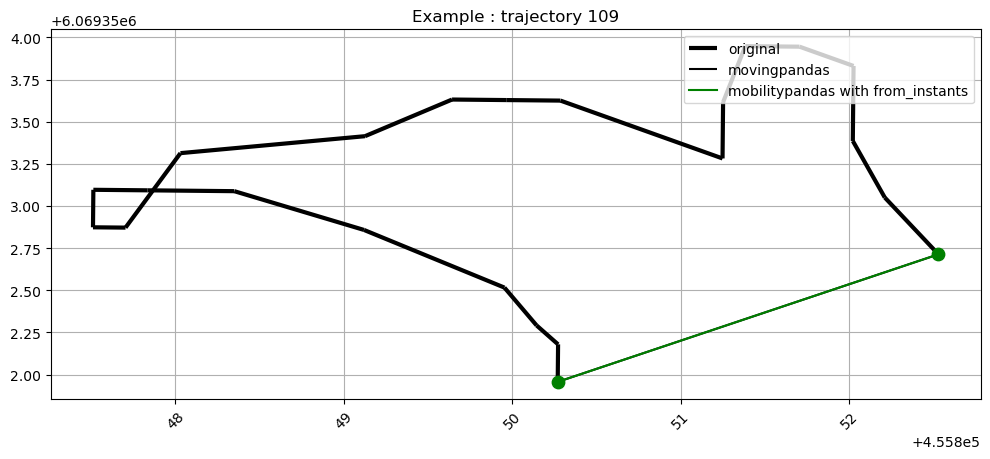

In [113]:

# Plotting the trajectories
# n=109
n=109
m = [traj.id for traj in trajectories_without][n]
print(m)

fig, ax = plt.subplots(figsize=(12, 8))
trajectories_without.trajectories[n].plot(color='black', label='original', linewidth=3, ax=ax)

# trajectories_without.trajectories[n].plot(color='black', label='movingpandas', linewidth=8, ax=ax)
# trajectories_with3.trajectory[m].plot(color='red', label='mobilitypandas with from_arrays', linewidth=5)
# trajectories_with2.trajectory[m].plot(color='blue', label='mobilitypandas with from_instants', linewidth=2)

simplified_without.trajectories[n].plot(color='black', label='movingpandas', ax=ax)
simplified_with2[m].plot(color='green', label='mobilitypandas with from_instants')
# simplified_with3.values[n].plot(color='blue', label='mobilitypandas with from_arrays', linewidth=2)

plt.title("Example : trajectory {0}".format(n))
plt.legend()
plt.show()


# print(simplified_without.trajectories[n].size(), simplified_with2.values[n].num_instants())
# print(trajectories_without.trajectories[n].get_start_location(), trajectories_with2.trajectory[m].start_value())
# print(simplified_without.trajectories[n].get_start_location(), simplified_with2.values[n].start_value())
# print()
# print(trajectories_without.trajectories[n], '\n\n', trajectories_with2.values[n])

def from_mmsi(collection, mmsi):
    if isinstance(collection, mpd.TrajectoryCollection):
        return next(
            traj for traj in collection.trajectories
            if 'mmsi' in traj.df.columns and traj.df['mmsi'].iloc[0] == mmsi
        )
    elif isinstance(collection, pd.Series):
        return next(
            traj for traj in collection.values
            if traj.index == mmsi
        )



## Visualisation

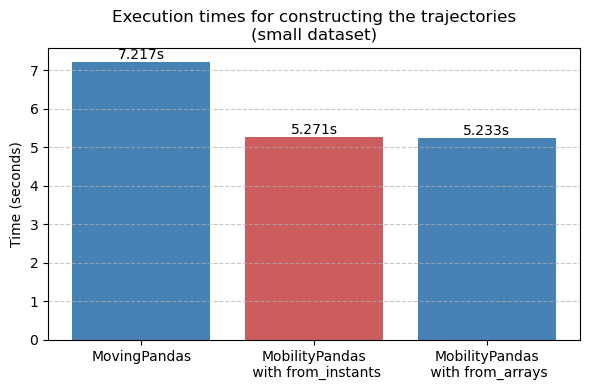

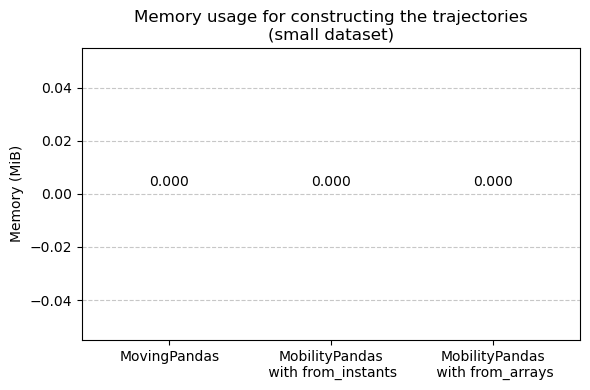

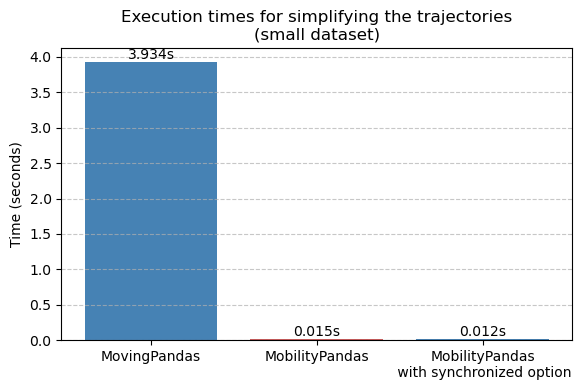

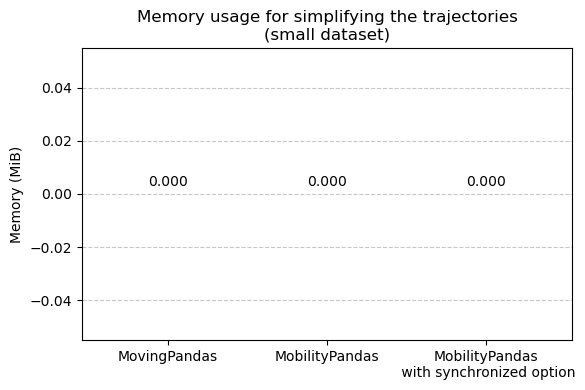

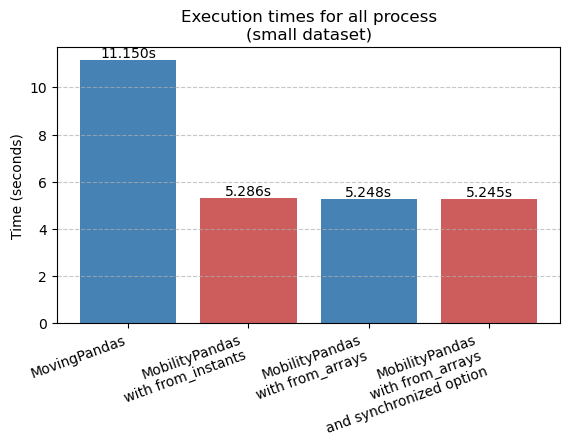

In [114]:

# Construction
timesCo = [results['extraction'][0] + results['construction_without'][0], results['extraction'][0]+ results['construction_from_instants'][0], 
         results['extraction'][0]+ results['construction_from_arrays'][0]]
memCo = [results['construction_without'][1], results['construction_from_instants'][1], results['construction_from_arrays'][1]]
libs = ['MovingPandas', 'MobilityPandas\n with from_instants', 'MobilityPandas\n with from_arrays']


plt.figure(figsize=(6, 4))
bars = plt.bar(libs, timesCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, memCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#Calculation
timesCa = [results['simplify_without'][0], results['simplify_with'][0], results['simplify_sync'][0]]
memCa = [results['simplify_without'][1], results['simplify_with'][1], results['simplify_sync'][1]]
libsCa = ['MovingPandas', 'MobilityPandas', 'MobilityPandas\n with synchronized option']

plt.figure(figsize=(6, 4))
bars = plt.bar(libsCa, timesCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libsCa, memCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Total
times = [results['extraction'][0] + results['construction_without'][0] + results['simplify_without'][0], 
         results['extraction'][0]+ results['construction_from_instants'][0] + results['simplify_with'][0], 
         results['extraction'][0]+ results['construction_from_arrays'][0] + results['simplify_with'][0],
         results['extraction'][0]+ results['construction_from_arrays'][0] + results['simplify_sync'][0]]

libs = ['MovingPandas', 'MobilityPandas\n with from_instants', 'MobilityPandas\n with from_arrays', 
        'MobilityPandas\n with from_arrays\nand synchronized option']

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, times, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for all process\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xticks(rotation=20, ha='right')
plt.show()
